In [5]:
# ==========================================
# STEP 1 :- Import Libraries & Load Dataset
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load dataset
# Make sure student.csv is in the same folder as notebook

df = pd.read_csv('student.csv')

# Display first 5 rows
print(df.head())

   student_id first_name   last_name  age                        email  \
0           1    Kerrill   De Cleyne   24          kdecleyne0@furl.net   
1           2    Krissie      Vittet   25          kvittet1@ustream.tv   
2           3   Hugibert       Haugg   21      hhaugg2@theguardian.com   
3           4     Fancie     De Mars   18       fdemars3@parallels.com   
4           5      Micki  O'Dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  total_score  
0    Venezuela          68             80             15           54  
1     Bulgaria          29             30             60           39  
2  New Zealand          76              0             55           43  
3        China          82             88             90           86  
4        China          77             23             11           37  


In [6]:
# ==========================================
# STEP 2 :- Data Understanding
# ==========================================

print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1000, 10)
Index(['student_id', 'first_name', 'last_name', 'age', 'email', 'country',
       'grade_math', 'grade_science', 'grade_english', 'total_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   object
 2   last_name      1000 non-null   object
 3   age            1000 non-null   int64 
 4   email          1000 non-null   object
 5   country        1000 non-null   object
 6   grade_math     1000 non-null   int64 
 7   grade_science  1000 non-null   int64 
 8   grade_english  1000 non-null   int64 
 9   total_score    1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB
None
        student_id          age   grade_math  grade_science  grade_english  \
count  1000.000000  1000.000000  1000.000000    1000.000000    10

In [7]:
# ==========================================
# STEP 3 :- Drop Unnecessary Columns
# ==========================================

df = df.drop([
    'student_id',
    'first_name',
    'last_name',
    'email'
], axis=1)

print(df.head())

   age      country  grade_math  grade_science  grade_english  total_score
0   24    Venezuela          68             80             15           54
1   25     Bulgaria          29             30             60           39
2   21  New Zealand          76              0             55           43
3   18        China          82             88             90           86
4   24        China          77             23             11           37


In [9]:
# ==========================================
# STEP 4 :- Encode Country Column
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['country'] = encoder.fit_transform(df['country'])

print(df.head())

   age  country  grade_math  grade_science  grade_english  total_score
0   24      113          68             80             15           54
1   25       13          29             30             60           39
2   21       75          76              0             55           43
3   18       19          82             88             90           86
4   24       19          77             23             11           37


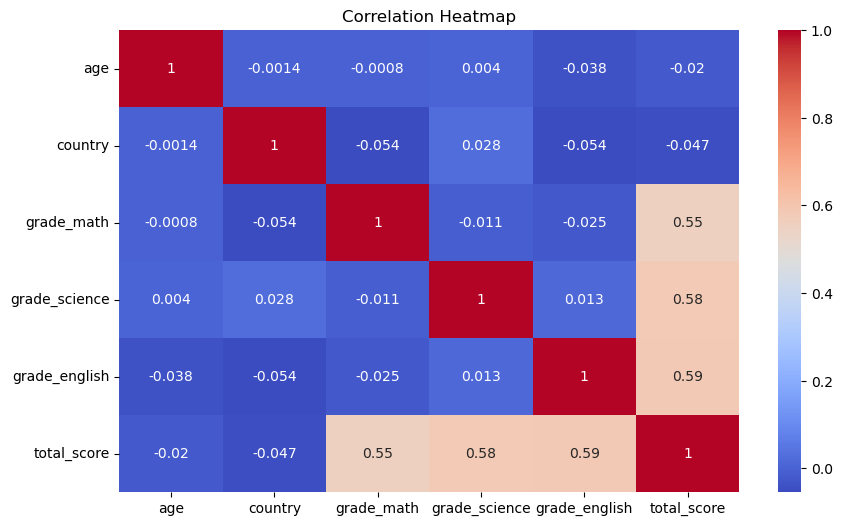

In [10]:
# ==========================================
# STEP 5 :- Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

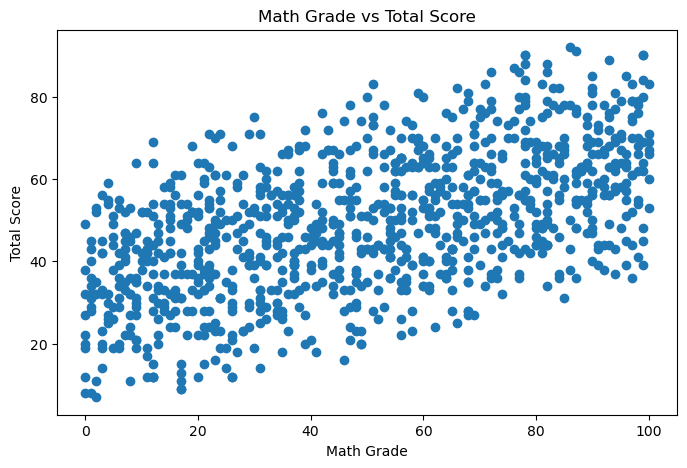

In [11]:
# ==========================================
# STEP 6 — Visualization
# ==========================================


plt.figure(figsize=(8,5))

plt.scatter(
    df['grade_math'],
    df['total_score']
)

plt.xlabel('Math Grade')
plt.ylabel('Total Score')
plt.title('Math Grade vs Total Score')

plt.show()

In [13]:
# ==========================================
# STEP 7 — Feature Selectionn
# ==========================================


X = df[[
    'age',
    'country',
    'grade_math',
    'grade_science',
    'grade_english'
]]
y = df['total_score']

In [14]:
# ==========================================
# STEP 9 — Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 5)
(200, 5)


In [15]:
# ==========================================
# STEP 10 — Train Model
# ==========================================


model = LinearRegression()

model.fit(X_train, y_train)

print('Model Trained Successfully')

Model Trained Successfully


In [16]:
# ==========================================
# STEP 11 — Prediction
# ==========================================


y_pred = model.predict(X_test)

print(y_pred[:10])

[77.29975624 44.66037035 36.34936616 56.67987307 51.00183583 66.32252781
 33.33526785 52.33261241 23.67821966 32.69393676]


In [17]:
# ==========================================
# STEP 12 — Evaluation
# ==========================================


mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)

print('R2 Score:', r2)

Mean Squared Error: 0.07898810157247156
R2 Score: 0.9996395587234282


In [18]:
# ==========================================
# STEP 13 — Predict New Student
# ==========================================


new_student = [[20, 1, 85, 90, 88]]

prediction = model.predict(new_student)

print('Predicted Total Score:', prediction[0])

Predicted Total Score: 87.32033765793446
